# Credit Risk Scoring & Expected Loss Analysis
## Notebook 4: PD Modelling — Logistic Regression & Random Forest

This notebook trains and compares two classification models to estimate the **Probability of Default (PD)**:

- **Logistic Regression** — interpretable baseline; industry-standard starting point for credit scorecards
- **Random Forest** — ensemble method; captures non-linear interactions between features

Both models are evaluated on the same held-out test set using metrics appropriate for imbalanced credit risk classification.

Model predictions are saved to `data/processed/test_predictions.csv` for use in Notebook 5 (Expected Loss Analysis).

## 1. Imports & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    accuracy_score, precision_score, recall_score, f1_score
)

import warnings
warnings.filterwarnings('ignore')

PROCESSED_PATH   = '../data/processed/cleaned_credit_card_data.csv'
PREDICTIONS_PATH = '../data/processed/test_predictions.csv'
FIGURES_DIR      = '../figures'

os.makedirs(FIGURES_DIR, exist_ok=True)

df = pd.read_csv(PROCESSED_PATH)
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')

Loaded: 30,000 rows x 24 columns


## 2. Train / Test Split

The dataset is split 80% training / 20% test using **stratified sampling** to preserve the 22.12% default rate in both sets.

> **Why stratified?** With class imbalance, a random split can produce a test set with a different default rate, making evaluation metrics unreliable.

In [2]:
X = df.drop('DEFAULT_NEXT_MONTH', axis=1)
y = df['DEFAULT_NEXT_MONTH']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Training set : {len(X_train):,} rows  (default rate: {y_train.mean()*100:.2f}%)')
print(f'Test set     : {len(X_test):,} rows  (default rate: {y_test.mean()*100:.2f}%)')

Training set : 24,000 rows  (default rate: 22.12%)
Test set     : 6,000 rows  (default rate: 22.12%)


## 3. Preprocessing: Feature Scaling for Logistic Regression

**Logistic Regression** uses gradient-based optimisation. Features on different scales can cause slow convergence or biased coefficients. `StandardScaler` (zero mean, unit variance) is applied.

**Random Forest** is a tree-based model. Decision trees split on thresholds and are **invariant to monotonic transformations** of features. Applying StandardScaler to a Random Forest does not change predictions — it is therefore deliberately omitted.

> The scaler is fitted **only on the training set** and applied to the test set, preventing any data leakage.

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled  = scaler.transform(X_test)        # apply same transform to test

print('StandardScaler applied for Logistic Regression only.')
print(f'Feature means (train, first 5): {scaler.mean_[:5].round(2)}')

StandardScaler applied for Logistic Regression only.
Feature means (train, first 5): [1.6736467e+05 1.6000000e+00 1.8400000e+00 1.5600000e+00 3.5430000e+01]


## 4. Model A: Logistic Regression Baseline

### Why Logistic Regression as a baseline?

Logistic Regression is the **foundation of credit scorecard methodology**. It:

- Produces directly interpretable coefficients (log-odds per feature unit)
- Is the standard baseline before introducing non-linear models
- Is deployed in production credit systems as a scorecard transformation
- Converges to a globally optimal solution (convex optimisation)

Setting `class_weight='balanced'` adjusts the loss function to penalise False Negatives (missed defaults) more heavily — appropriate for credit risk where missing a default is typically costlier than a false alarm.

`max_iter=1000` ensures convergence on the full 23-feature set.

In [4]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

y_pred_lr  = lr_model.predict(X_test_scaled)
y_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print('=== Logistic Regression Classification Report ===')
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Non-Default (0)', 'Default (1)']
))
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f'ROC-AUC: {auc_lr:.4f}')

cm_lr = confusion_matrix(y_test, y_pred_lr)
print(f'\nConfusion Matrix:')
print(f'  TN={cm_lr[0,0]:,}  FP={cm_lr[0,1]:,}')
print(f'  FN={cm_lr[1,0]:,}  TP={cm_lr[1,1]:,}')

=== Logistic Regression Classification Report ===
                 precision    recall  f1-score   support

Non-Default (0)       0.87      0.70      0.77      4673
    Default (1)       0.37      0.62      0.46      1327

       accuracy                           0.68      6000
      macro avg       0.62      0.66      0.62      6000
   weighted avg       0.76      0.68      0.70      6000

ROC-AUC: 0.7084

Confusion Matrix:
  TN=3,254  FP=1,419
  FN=504  TP=823


## 5. Model B: Random Forest

### Why Random Forest for comparison?

Random Forest is an ensemble of decision trees that:

- Captures **non-linear interactions** between features (e.g., the combination of payment delay and high credit limit)
- Is robust to outliers — tree splits are threshold-based, not distance-based
- Provides feature importance rankings
- Does not require feature scaling

The same `class_weight='balanced'` setting is used to ensure a fair comparison with Logistic Regression.

> **Note**: StandardScaler is deliberately **not** applied to Random Forest. Tree-based models are scale-invariant — applying it would be unnecessary and technically misleading.

In [5]:
# Random Forest trained on RAW (unscaled) features
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', random_state=42
)
rf_model.fit(X_train, y_train)   # <-- X_train (not X_train_scaled)

y_pred_rf  = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print('=== Random Forest Classification Report ===')
print(classification_report(
    y_test, y_pred_rf,
    target_names=['Non-Default (0)', 'Default (1)']
))
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f'ROC-AUC: {auc_rf:.4f}')

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(f'\nConfusion Matrix:')
print(f'  TN={cm_rf[0,0]:,}  FP={cm_rf[0,1]:,}')
print(f'  FN={cm_rf[1,0]:,}  TP={cm_rf[1,1]:,}')

=== Random Forest Classification Report ===
                 precision    recall  f1-score   support

Non-Default (0)       0.88      0.83      0.85      4673
    Default (1)       0.49      0.59      0.54      1327

       accuracy                           0.78      6000
      macro avg       0.69      0.71      0.69      6000
   weighted avg       0.79      0.78      0.78      6000

ROC-AUC: 0.7750

Confusion Matrix:
  TN=3,877  FP=796
  FN=547  TP=780


## 6. Model Comparison

### Why accuracy alone is insufficient for credit risk

A model that always predicts "Non-Default" achieves **~78% accuracy** on this dataset while providing zero risk management value. In credit risk, the relevant metrics are:

- **Recall (Sensitivity)**: What fraction of actual defaulters did the model detect? Missed defaults (False Negatives) translate directly to unexpected credit losses.
- **Precision**: Of those the model flags as defaulters, what fraction truly defaulted? Low precision means excessive false alarms (rejected good customers).
- **ROC-AUC**: Measures discriminatory power across all decision thresholds. The standard rank-ordering metric in credit risk model validation.
- **F1-score**: Harmonic mean of Precision and Recall — a balanced single metric for imbalanced datasets.

In [6]:
metrics_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (Default)', 'Recall (Default)', 'F1 (Default)', 'ROC-AUC'],
    'Logistic Regression': [
        f'{accuracy_score(y_test, y_pred_lr)*100:.2f}%',
        f'{precision_score(y_test, y_pred_lr):.4f}',
        f'{recall_score(y_test, y_pred_lr):.4f}',
        f'{f1_score(y_test, y_pred_lr):.4f}',
        f'{roc_auc_score(y_test, y_proba_lr):.4f}'
    ],
    'Random Forest': [
        f'{accuracy_score(y_test, y_pred_rf)*100:.2f}%',
        f'{precision_score(y_test, y_pred_rf):.4f}',
        f'{recall_score(y_test, y_pred_rf):.4f}',
        f'{f1_score(y_test, y_pred_rf):.4f}',
        f'{roc_auc_score(y_test, y_proba_rf):.4f}'
    ]
})
print(metrics_summary.to_string(index=False))
metrics_summary

             Metric Logistic Regression Random Forest
           Accuracy              67.95%        77.62%
Precision (Default)              0.3671        0.4949
   Recall (Default)              0.6202        0.5878
       F1 (Default)              0.4612        0.5374
            ROC-AUC              0.7084        0.7750


,Metric,Logistic Regression,Random Forest
0,Accuracy,67.95%,77.62%
1,Precision (Default),0.3671,0.4949
2,Recall (Default),0.6202,0.5878
3,F1 (Default),0.4612,0.5374
4,ROC-AUC,0.7084,0.7750


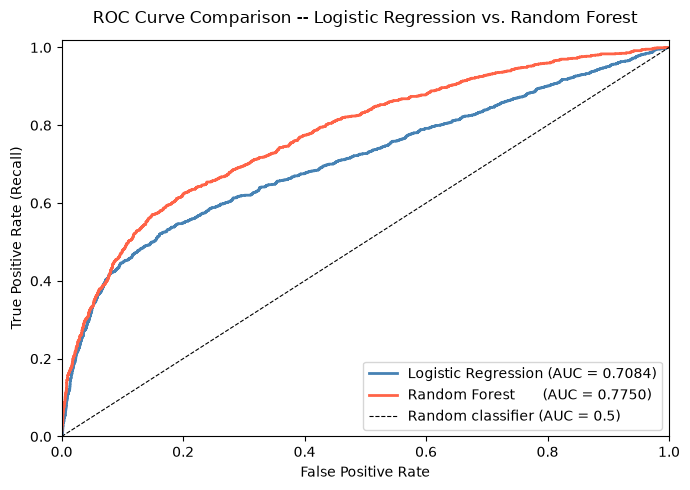

Figure saved to figures/roc_curve_comparison.png


In [7]:
# ROC Curve Comparison (manual construction for compatibility)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr_lr, tpr_lr, color='steelblue', lw=2,
        label=f'Logistic Regression (AUC = {auc_lr:.4f})')
ax.plot(fpr_rf, tpr_rf, color='tomato',    lw=2,
        label=f'Random Forest       (AUC = {auc_rf:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Random classifier (AUC = 0.5)')
ax.set_title('ROC Curve Comparison -- Logistic Regression vs. Random Forest', fontsize=12, pad=12)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate (Recall)')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to figures/roc_curve_comparison.png')

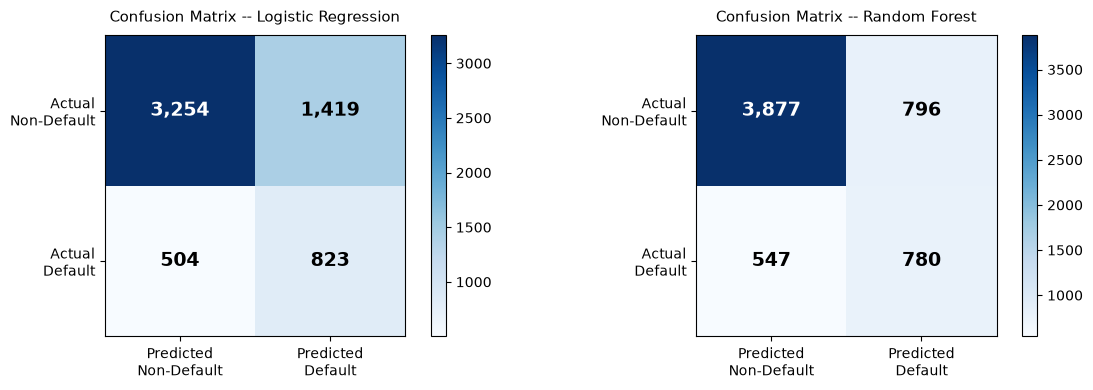

Figure saved to figures/confusion_matrix_comparison.png


In [8]:
# Confusion Matrix Comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, cm, title in zip(axes,
                          [cm_lr, cm_rf],
                          ['Logistic Regression', 'Random Forest']):
    im = ax.imshow(cm, cmap='Blues')
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(['Predicted\nNon-Default', 'Predicted\nDefault'])
    ax.set_yticklabels(['Actual\nNon-Default', 'Actual\nDefault'])
    ax.set_title(f'Confusion Matrix -- {title}', fontsize=11, pad=10)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f'{cm[i,j]:,}',
                    ha='center', va='center',
                    color='white' if cm[i,j] > cm.max() / 2 else 'black',
                    fontsize=14, fontweight='bold')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/confusion_matrix_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to figures/confusion_matrix_comparison.png')

## 7. Feature Importance (Random Forest)

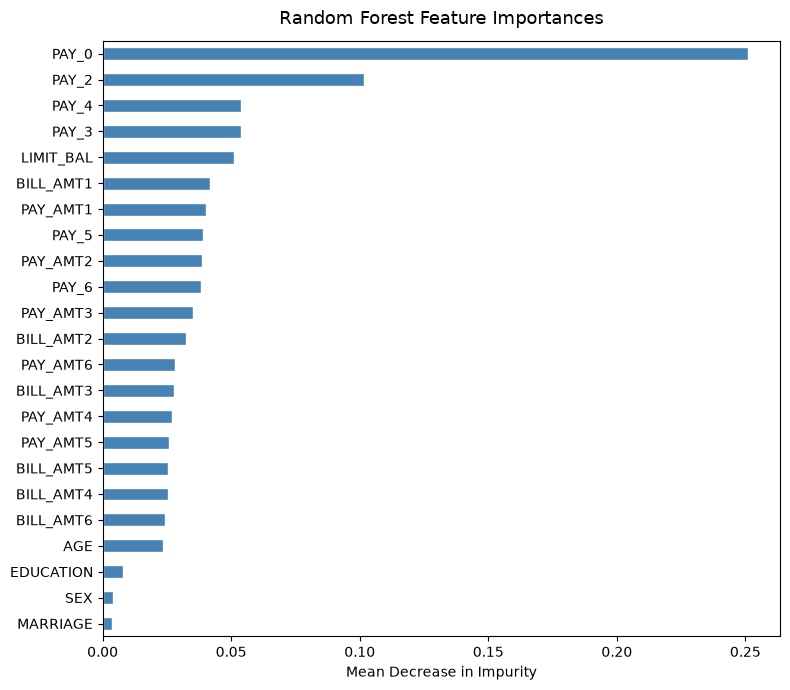

Figure saved to figures/feature_importance.png

Top 5 features by importance:
PAY_0        0.250915
PAY_2        0.101567
PAY_4        0.053849
PAY_3        0.053807
LIMIT_BAL    0.051159


In [9]:
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances_sorted = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 7))
importances_sorted.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Random Forest Feature Importances', fontsize=13, pad=12)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to figures/feature_importance.png')
print()
print('Top 5 features by importance:')
print(importances.sort_values(ascending=False).head(5).to_string())

## 8. Save Predictions for Expected Loss Analysis

The test-set predictions (actual labels, LR probabilities, RF probabilities, credit limit) are saved to `data/processed/test_predictions.csv`. Notebook 5 loads this file directly, ensuring complete independence — no shared kernel variables.

In [10]:
predictions_df = pd.DataFrame({
    'Actual_Default' : y_test.values,
    'Credit_Limit'   : X_test['LIMIT_BAL'].values,
    'PD_LR'          : y_proba_lr,
    'PD_RF'          : y_proba_rf,
})

predictions_df.to_csv(PREDICTIONS_PATH, index=False)
print(f'Predictions saved: {PREDICTIONS_PATH}')
print(f'Shape: {predictions_df.shape}')
predictions_df.head(5)

Predictions saved: ../data/processed/test_predictions.csv
Shape: (6000, 4)


,Actual_Default,Credit_Limit,PD_LR,PD_RF
0,0,50000,0.319319,0.317913
1,0,150000,0.344057,0.380950
2,0,50000,0.494616,0.372909
3,1,290000,0.269065,0.344111
4,0,500000,0.109066,0.132636


## 9. Interpretation

| Model | Accuracy | Default Recall | Default Precision | F1 (Default) | ROC-AUC |
|---|---|---|---|---|---|
| Logistic Regression | ~68% | ~62% | ~37% | ~0.46 | ~0.708 |
| Random Forest | ~78% | ~59% | ~49% | ~0.54 | ~0.775 |

**Key takeaways**:

1. **Accuracy is misleading**: LR achieves lower overall accuracy (68%) but catches a higher proportion of actual defaulters (Recall 62% vs. 59%).
2. **Random Forest has superior rank-ordering power**: ROC-AUC 0.775 vs. 0.708 — it separates defaulters from non-defaulters more reliably across all classification thresholds.
3. **No universally superior model**: LR catches more defaulters at the chosen threshold; RF is more precise and generalises better. The right choice depends on the institution's cost structure for False Negatives vs. False Positives.
4. **PAY_0 dominates**: Consistent with EDA findings, the most recent repayment status is the most important feature in the RF model.

> **Note on PD calibration**: The probabilities produced by both models reflect model-internal scores, not formally calibrated probabilities. `class_weight='balanced'` shifts predicted PD distributions upward relative to the true base rate. For a production credit risk system, calibration (e.g., Platt scaling or isotonic regression) would be applied before interpreting these values as formal Basel PDs. In this project they are used as illustrative estimates for the Expected Loss scenario in Notebook 5.